In [1]:
import os
import numpy as np
import pandas as pd

import geopandas as gpd

import cmocean.cm as cmo

import xarray as xr
import rasterio
import rasterio.plot as rplt
from affine import Affine

from shapely.geometry import LineString, Point


import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1 import make_axes_locatable

import app
import logging
logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)

app.setup_logger(use_console_handler=True, use_file_handler=False)

In [2]:
base_directory = r"D:\PhD\21_Experiments\TidesDamageDriver"
extent_folder = os.path.join(
    base_directory, "03_cleaned", "L8S2-tucket_extents_vector"
)
drainages_folder = os.path.join(
    base_directory, "02_processed", "03_drainages"
)
coastline_folder = os.path.join(
    base_directory, "01_raw", "greene2022_coastlines"
)
iceshelf_folder = os.path.join(
    base_directory, "01_raw", "greene2022_iceshelves"
)
add_path = os.path.join(
    base_directory, "01_raw", "high_res_coastline", "add_coastline_high_res_line_v7_6.shp"
)

grid_path = os.path.join(
    base_directory, "01_raw", "grid", "ne_110m_graticules_1.shp"
)
figure_folder = os.path.join(
    base_directory, "figures"
)

In [3]:
years = [2016, 2018, 2019, 2020]
xmin = 2.50e6
xmax = 2.77e6
ymax = -0.215e6
ymin = -0.591e6
vertical_line = LineString([(xmin, ymin), (xmin, ymax)])

In [4]:
grid = gpd.read_file(grid_path)  # https://www.naturalearthdata.com/about/terms-of-use/
grid.to_crs("EPSG:3031", inplace=True)
grid = grid.cx[xmin:xmax, ymin:ymax]

grid_filtered = gpd.GeoDataFrame(grid[grid["degrees"].isin([65, 66, 100, 95])].cx[xmin: xmax, ymin: ymax])
grid_filtered_S = grid_filtered.query("direction == 'S'")
grid_filtered_E = grid_filtered.query("direction == 'E'")

label_points_grid = []

for idx, row in grid_filtered.iterrows():
    line = row.geometry
    intersection = line.intersection(vertical_line)

    if not intersection.is_empty:
        if intersection.geom_type == "Point":
            x_int, y_int = intersection.x, intersection.y
            if ymin <= y_int <= ymax:
                label_points_grid.append({
                    "label": row["display"],
                    "x": x_int,
                    "y": y_int
                })
        elif intersection.geom_type in ["MultiPoint", "GeometryCollection"]:
            for geom in intersection.geoms:
                if geom.geom_type == "Point":
                    x_int, y_int = geom.x, geom.y
                    if ymin <= y_int <= ymax:
                        label_points_grid.append({
                            "label": row["display"],
                            "x": x_int,
                            "y": y_int
                        })
grid.head()

,degrees,direction,display,scalerank,dd,geometry
154,65,S,65 S,6,-65,"LINESTRING (-2.112e-9 -2758494.765, 161.696 -2..."
155,66,S,66 S,6,-66,"LINESTRING (2.365 -2644909.451, 155.038 -26449..."
156,67,S,67 S,6,-67,"LINESTRING (2.264 -2531747.008, 148.404 -25317..."
256,103,E,103 E,6,103,"LINESTRING (7.141 -1.648, 52938.639 -12219.281..."
257,102,E,102 E,6,102,"LINESTRING (7.169 -1.523, 53143.83 -11293.522,..."


In [ ]:
all_coastline_files = os.listdir(coastline_folder)
coastlines = [
    gpd.read_file(os.path.join(coastline_folder, f)).cx[xmin:xmax, ymin:ymax]
    for f in all_coastline_files
    if f.endswith(".shp") and any([str(s) in f for s in years])
]
# buffer = 6e3
# coastlines_buffer = [c.buffer(buffer) for c in coastlines]

In [24]:
all_iceshelves_files = os.listdir(iceshelf_folder)
iceshelves = [
    gpd.read_file(os.path.join(iceshelf_folder, f)).cx[xmin:xmax, ymin:ymax]
    for f in all_iceshelves_files
    if f.endswith(".shp") and any([str(s) in f for s in years])
]
ice_buffer = 150
for ice in iceshelves:
    ice.geometry = ice.buffer(ice_buffer)
    ice = ice.dissolve()
    ice.geometry = ice.buffer(-ice_buffer)
cmap = mpl.colormaps["cmo.ice"]
ice_colors = cmap(np.linspace(0.2, 0.8, 3))

buffer = 1e3
iceshelves_buffer = [i.buffer(buffer) for i in iceshelves]

(-591000.0, -215000.0)

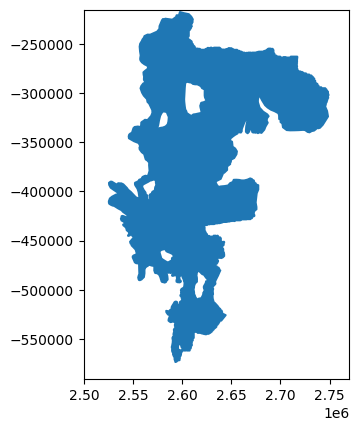

In [25]:
fig, ax = plt.subplots()

iceshelves_buffer[0].plot(ax = ax)
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

In [27]:
extent_files = [f for f in os.listdir(extent_folder) if f.endswith(".shp")]
extent_paths = [os.path.join(extent_folder, f) for f in extent_files]
extents = []
extents_reduced = []
for i_year, year in enumerate(years):
    year_files = [p for p in extent_paths if f"{year}" in p]
    extent = gpd.read_file(year_files[0])
    extents.append(extent)
    reduced = extent[extent.within(iceshelves_buffer[i_year].union_all())]
    extents_reduced.append(reduced)
    print(year, f"{extent.area.sum() / 1e6:.2f}", f"{reduced.area.sum() / 1e6:.2f}")  # m^2 to km^2
buffer = 2e2
extents_buffered = [e.buffer(buffer) for e in extents]

2016 282.56 150.20
2018 349.97 213.13
2019 321.79 215.01
2020 375.95 152.09


In [ ]:
add = gpd.read_file(
    add_path
)
add.columns
add["surface"].unique()

shelf_lines = add[add["surface"].isin(["ice shelf and front"])]
grounding_lines = add[
    add["surface"].isin(
        [
            "ice coastline",
            "grounding line",
            "ice rumples",
            "rock against ice shelf",
            "rock coastline",
        ]
    )
]

shelf = shelf_lines.cx[xmin:xmax, ymin:ymax]
grounding_line = grounding_lines.cx[xmin:xmax, ymin:ymax]

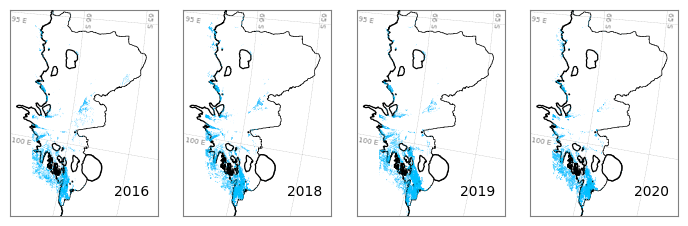

In [30]:
total_width = 18 / 2.54
gird_label_font_size = 5
fig, axes = plt.subplots(1, 4, figsize=(total_width, 6 / 2.54), sharex=True, sharey=True)

for i_year, year in enumerate(years):
    ax = axes.ravel()[i_year]
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    grid_filtered.plot(ax=ax, color="gray", linewidth=0.2, alpha=0.8, ls="--", zorder = 15)
    coastlines[i_year].plot(ax=ax, facecolor="none", edgecolor="black", lw=0.5, zorder = 3)
    grounding_line.plot(ax=ax, facecolor="none", edgecolor="black", lw=0.9, zorder = 3)

    extents_buffered[i_year].plot(ax=ax, facecolor="deepskyblue", zorder = 10, alpha =0.8)

    # S labels (assume all same Y)
    ys = np.full(len(grid_filtered_S), ymax - 3e3)
    xs = grid_filtered_S.bounds.maxx - 5e3
    labels = grid_filtered_S['degrees'].astype(str) + ' S'

    for x, y, s in zip(xs, ys, labels):
        ax.text(x, y, s, rotation=-96, ha="center", va="top",
                fontsize=gird_label_font_size, color="gray", zorder=16)

    # E labels (assume all same Y)
    label_lookup = {l['label']: l['y'] for l in label_points_grid}
    xs = np.full(len(grid_filtered_E), xmin + 2e3)
    ys = grid_filtered_E['display'].map(label_lookup) - 1.5e4
    labels = grid_filtered_E['degrees'].astype(str) + ' E'

    for x, y, s in zip(xs, ys, labels):
        ax.text(x, y, s, rotation=-9, ha="left", va="center",
                fontsize=gird_label_font_size, color="gray", zorder=16)

    ax.tick_params(
            axis="both",  # changes apply to the x-axis
            which="both",  # both major and minor ticks are affected
            bottom=False,  # ticks along the bottom edge are off
            top=False,  # ticks along the top edge are off
            left=False,
            right=False,
            labelbottom=False,
            labelleft=False,
        )
    ax.text(x = 0.7, y = 0.1, s=str(year), transform=ax.transAxes)
    
    ax.spines["bottom"].set_color("gray")
    ax.spines["top"].set_color("gray")
    ax.spines["left"].set_color("gray")
    ax.spines["right"].set_color("gray")

plt.tight_layout()
plt.savefig(
    os.path.join(figure_folder, f"figure_S3_extents.png"),
    dpi=300,
)
plt.savefig(
    os.path.join(figure_folder, f"figure_S3_extents.pdf"),
    dpi=300,
)
plt.show()